In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares

# I-B plot

In [2]:
df = pd.read_csv("mag_lin.csv")
display(df)
df.columns

,z[cm],y[cm],x dal Nord[cm] pm 0.1,I[A] pm 0.1,Bmax[g] pm 0.1,err
0,0.0,20.0,60,1.0,3.7,0.1
1,NaN,NaN,40,1.0,3.8,0.2
2,NaN,NaN,20,1.0,3.8,0.2
3,NaN,NaN,20,1.5,5.2,0.4
4,NaN,NaN,40,1.5,5.3,0.2
...,...,...,...,...,...,...
76,NaN,NaN,40,13.5,42.9,0.2
77,NaN,NaN,60,13.5,43.5,0.2
78,NaN,NaN,60,14.0,44.9,0.2
79,NaN,NaN,40,14.0,44.2,0.2


Index(['z[cm] ', ' y[cm] ', ' x dal Nord[cm] pm 0.1', 'I[A] pm 0.1',
       'Bmax[g] pm 0.1', ' err'],
      dtype='object')

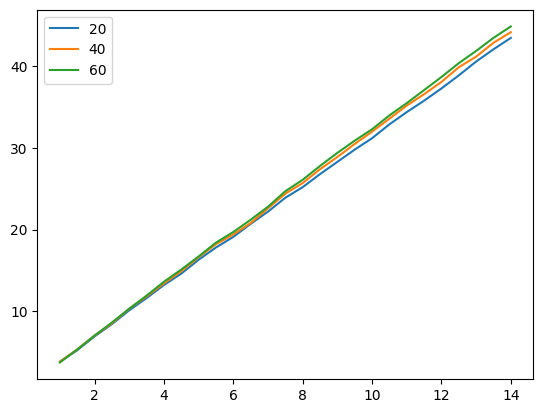

In [3]:
dist20 = df[df[" x dal Nord[cm] pm 0.1"] == 20.0]
dist40 = df[df[" x dal Nord[cm] pm 0.1"] == 40.0]
dist60 = df[df[" x dal Nord[cm] pm 0.1"] == 60.0]

plt.plot( dist20["I[A] pm 0.1"] , dist20["Bmax[g] pm 0.1"] , label="20")
plt.plot( dist40["I[A] pm 0.1"] , dist40["Bmax[g] pm 0.1"] , label = "40")
plt.plot( dist60["I[A] pm 0.1"] , dist60["Bmax[g] pm 0.1"] , label = "60")
plt.legend()
plt.show()

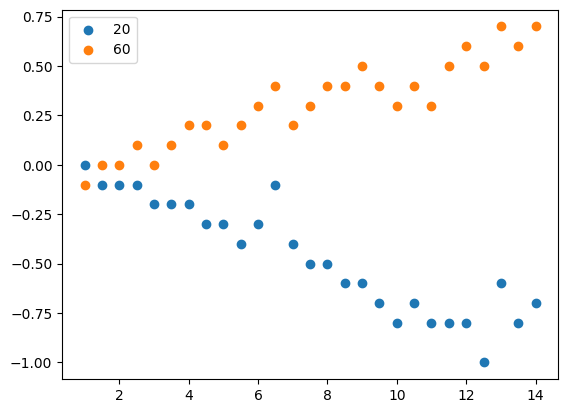

In [4]:
plt.scatter( dist20["I[A] pm 0.1"] , dist20["Bmax[g] pm 0.1"].to_numpy() - dist40["Bmax[g] pm 0.1"].to_numpy() , label="20")
plt.scatter( dist20["I[A] pm 0.1"] , dist60["Bmax[g] pm 0.1"].to_numpy() - dist40["Bmax[g] pm 0.1"].to_numpy() , label="60")
plt.legend()
plt.show()

In [10]:
earthMagneticField = 0.47845

def linear(x , a , b):
    return a*x + b

d20 = LeastSquares( dist20["I[A] pm 0.1"] , dist20["Bmax[g] pm 0.1"] , dist20[" err"] , linear)
d40 = LeastSquares( dist40["I[A] pm 0.1"] , dist40["Bmax[g] pm 0.1"] , dist40[" err"] , linear)
d60 = LeastSquares( dist60["I[A] pm 0.1"] , dist60["Bmax[g] pm 0.1"] , dist60[" err"] , linear)

m2 = Minuit( d20 , a = 1 , b = earthMagneticField)
m4 = Minuit( d40 , a = 1 , b = earthMagneticField)
m6 = Minuit( d60 , a = 1 , b = earthMagneticField)
m2.fixed["b"] = True
m4.fixed["b"] = True
m6.fixed["b"] = True
m2.migrad()
m4.migrad()
m6.migrad()

display(m2)
display(m4)
display(m6)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 24.45 (χ²/ndof = 0.9)      │              Nfcn = 15               │
│ EDM = 5.96e-13 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   3.087   │   0.005   │            │            │         │         │       │
│ 1 │ b    │   0.478   │   0.005   │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 2.15e-05        0 │
│ b │        0        0 │
└───┴───────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 27.1 (χ²/ndof = 1.0)       │              Nfcn = 15               │
│ EDM = 8.7e-14 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   3.151   │   0.005   │            │            │         │         │       │
│ 1 │ b    │   0.478   │   0.005   │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 2.14e-05        0 │
│ b │        0        0 │
└───┴───────────────────┘

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 15.67 (χ²/ndof = 0.6)      │              Nfcn = 15               │
│ EDM = 3.95e-15 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   3.194   │   0.005   │            │            │         │         │       │
│ 1 │ b    │   0.478   │   0.005   │            │            │         │         │  yes  │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 2.12e-05        0 │
│ b │        0        0 │
└───┴───────────────────┘

# uniformity

In [19]:
df = pd.read_csv("unif.csv")

# display(df)
data = df.iloc[:,1:]

y_arr = df[df.columns[0]].to_list()
x_arr = data.columns.to_list()

# display(data)

y = y_arr * len(x_arr)
a = [[i]*len(y_arr) for i in x_arr]
x = []
for i in a:
    x+=i

z = np.ones_like(x)

(108,)


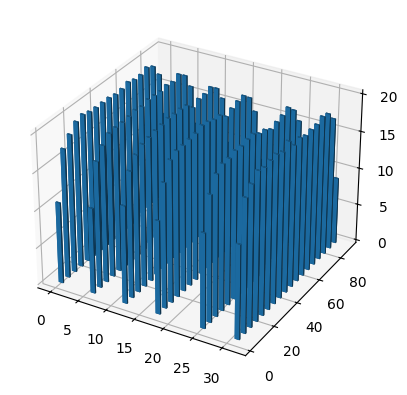

In [24]:
fig = plt.figure()
ax = fig.add_subplot( projection="3d")

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)
z = np.zeros_like(x, dtype=float)
dx = np.full_like(z, 0.8, dtype=float)
dy = np.full_like(z, 0.8, dtype=float)
dz = data.unstack().to_numpy()

print(np.shape(dz))

ax.bar3d(x , y , z , dx , dy , dz)

Text(0.5, 23.52222222222222, 'x [cm]')

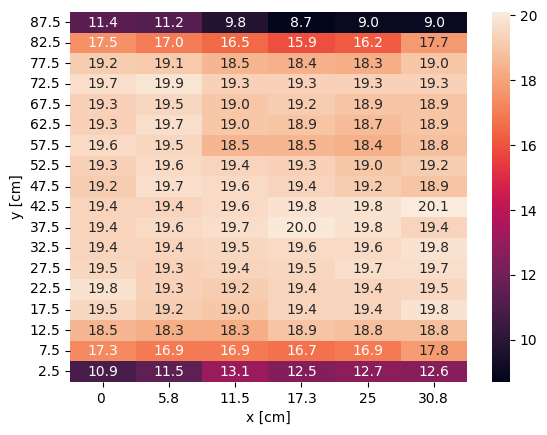

In [28]:
import seaborn as sb

ax = sb.heatmap(data, annot=True, fmt=".1f", yticklabels=y_arr, xticklabels=data.columns)
ax.invert_yaxis()
ax.set_ylabel("y [cm]")
ax.set_xlabel("x [cm]")